<!-- @@COLAB@@ -->
<a href="https://colab.research.google.com/github/nat-build-with-oracle/ajfon-oracle/blob/main/book/notebooks/ch10_chroma_to_lancedb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **เปิดใน Google Colab** — คลิกป้ายด้านบน รันได้ทันทีบนคลาวด์ฟรี ไม่ต้องติดตั้งอะไรในเครื่อง (เซลล์แรกจะ `pip install` ให้เอง)


# 📗 บทที่ 10 — เรื่องเล่าจริง: ทำไม ARRA ย้าย ChromaDB → LanceDB

**คู่กับ:** หนังสือบทที่ 10

เราสอนด้วย ChromaDB มาทั้งเล่ม (เหมาะเรียน: pip เดียว, API ตรง) — แต่ ARRA production
ย้ายไป **LanceDB** ปลายปี 2025 · บทนี้รันทั้งสองตัว**เทียบกันบนข้อมูลเดียวกัน** แล้วดูว่าทำไม


In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    %pip -q install chromadb lancedb sentence-transformers pandas
import time, shutil
import chromadb, lancedb
print('พร้อม ✓')


พร้อม ✓


In [2]:
# ---- embed อัจฉริยะ ----
import urllib.request, json
import numpy as np

def _ollama_ok():
    try:
        urllib.request.urlopen('http://localhost:11434/api/tags', timeout=2); return True
    except Exception:
        return False

if _ollama_ok():
    def embed_texts(texts):
        req = urllib.request.Request('http://localhost:11434/api/embed',
            data=json.dumps({'model': 'bge-m3', 'input': list(texts)}).encode(),
            headers={'Content-Type': 'application/json'})
        with urllib.request.urlopen(req, timeout=180) as r:
            V = np.array(json.load(r)['embeddings'])
        return V / np.linalg.norm(V, axis=1, keepdims=True)
    print('embed: Ollama bge-m3 ✓')
else:
    from sentence_transformers import SentenceTransformer
    _m = SentenceTransformer('BAAI/bge-m3')
    def embed_texts(texts):
        return _m.encode(list(texts), normalize_embeddings=True)
    print('embed: sentence-transformers ✓')


embed: Ollama bge-m3 ✓


## 1) corpus เดียวกัน 200 chunk (ขยายจากโน้ตจริง)


In [3]:
BASE = [
    'แผน workshop สอน vector search ให้นักวิจัย',
    'งานวิจัย embedding หลายภาษา bge-m3 GAP 0.393',
    'สูตรกาแฟ cold brew แช่ 18 ชั่วโมง',
    'PR #2740 แก้ drift benchmark',
    'บันทึกการเงิน ค่าอุปกรณ์แล็บเดือนกรกฎาคม',
]
DOCS = [f'{b} (ฉบับที่ {i})' for i in range(40) for b in BASE]
V = embed_texts(DOCS)
print(f'{len(DOCS)} chunks · {V.shape[1]} มิติ')


200 chunks · 1024 มิติ


## 2) ใส่ทั้งสองตัว — จับเวลา ingest


In [4]:
# --- ChromaDB ---
shutil.rmtree('./bench_chroma', ignore_errors=True)
cc = chromadb.PersistentClient(path='./bench_chroma')
ccol = cc.create_collection('bench', metadata={'hnsw:space': 'cosine'})
t0 = time.perf_counter()
ccol.add(ids=[str(i) for i in range(len(DOCS))], documents=DOCS, embeddings=V.tolist())
chroma_ingest = time.perf_counter() - t0

# --- LanceDB ---
shutil.rmtree('./bench_lance', ignore_errors=True)
ldb = lancedb.connect('./bench_lance')
t0 = time.perf_counter()
tbl = ldb.create_table('bench', data=[
    {'id': str(i), 'text': d, 'vector': v.tolist()} for i, (d, v) in enumerate(zip(DOCS, V))
])
lance_ingest = time.perf_counter() - t0

print(f'ingest 200 chunks → Chroma {chroma_ingest*1000:.0f} ms · LanceDB {lance_ingest*1000:.0f} ms')


ingest 200 chunks → Chroma 38 ms · LanceDB 11 ms


## 3) query เทียบกัน — ผลต้องตรงกัน (สมการเดียวกัน!)


In [5]:
q = 'โมเดลไหนเหมาะกับภาษาไทย'
qv = embed_texts([q])[0]

t0 = time.perf_counter()
for _ in range(10):
    cres = ccol.query(query_embeddings=[qv.tolist()], n_results=3)
chroma_q = (time.perf_counter() - t0) / 10 * 1000

t0 = time.perf_counter()
for _ in range(10):
    lres = tbl.search(qv.tolist()).distance_type('cosine').limit(3).to_list()
lance_q = (time.perf_counter() - t0) / 10 * 1000

print(f'query: Chroma {chroma_q:.1f} ms · LanceDB {lance_q:.1f} ms')
print()
print('Chroma top-1: ', cres['documents'][0][0][:50])
print('LanceDB top-1:', lres[0]['text'][:50])
print()
print('→ สังเกต: LanceDB ต้องระบุ .distance_type(\'cosine\') เหมือนกัน — ARRA เขียนไว้ใน lancedb.ts บรรทัดเดียวกันนี้')


query: Chroma 0.8 ms · LanceDB 2.1 ms

Chroma top-1:  งานวิจัย embedding หลายภาษา bge-m3 GAP 0.393 (ฉบับ
LanceDB top-1: งานวิจัย embedding หลายภาษา bge-m3 GAP 0.393 (ฉบับ

→ สังเกต: LanceDB ต้องระบุ .distance_type('cosine') เหมือนกัน — ARRA เขียนไว้ใน lancedb.ts บรรทัดเดียวกันนี้


## 4) แล้วต่างกันตรงไหน? — เหตุผลที่ ARRA ย้ายจริง (จาก TIMELINE.md)

| | ChromaDB (ยุคแรก ARRA, Dec 2025) | LanceDB (ปัจจุบัน) |
|---|---|---|
| runtime | ตอนนั้นต้องมี **Python sidecar** | **ฝังใน process** (Rust core) — Bun/Node เรียกตรง |
| storage | SQLite+parquet ภายใน | **Lance columnar** — versioned dataset (time-travel ได้) |
| ecosystem | Python เป็นหลัก | JS/TS native ← ARRA เป็น Bun/TypeScript! |
| เหมาะกับ | เรียนรู้/prototype Python | ฝังใน app จริงที่ไม่ใช่ Python |

**บทเรียน:** ไม่มีตัวไหน "ดีกว่า" ลอยๆ — ARRA เป็นแอป TypeScript จึงย้ายไปตัวที่ฝังใน runtime ตัวเองได้
ถ้าโปรเจกต์คุณเป็น Python notebook → ChromaDB ก็คือคำตอบที่ถูกแล้ว (scale-appropriate!)


## ✅ วัดผลตัวเอง #10


In [6]:
assert cres['documents'][0][0] == lres[0]['text'], 'top-1 สองระบบต้องตรงกัน (cosine เดียวกัน)'
assert chroma_q < 100 and lance_q < 100, 'ทั้งคู่ควรตอบใน <100ms ที่ 200 chunks'
print('✅ ผ่าน! สองระบบให้ top-1 ตรงกันเป๊ะ — เพราะสมการเดียวกัน (บทที่ 4)')
print('→ DB เปลี่ยนได้เสมอ ความรู้เรื่อง embedding+cosine+hybrid ติดตัวไปทุกระบบ')


✅ ผ่าน! สองระบบให้ top-1 ตรงกันเป๊ะ — เพราะสมการเดียวกัน (บทที่ 4)
→ DB เปลี่ยนได้เสมอ ความรู้เรื่อง embedding+cosine+hybrid ติดตัวไปทุกระบบ


## 📊 เห็นภาพ — Chroma vs LanceDB (เวลา, 200 chunks)


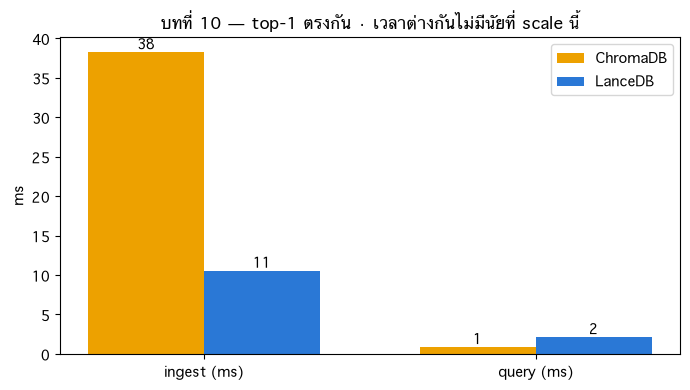

In [7]:
# @@VIZ@@
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
_thai_fonts=['Thonburi','Loma','Sarabun','Noto Sans Thai','TH Sarabun New']
_av={f.name for f in _fm.fontManager.ttflist}
if not any(_f in _av for _f in _thai_fonts):
    # Colab/Linux ไม่มีฟอนต์ไทยติดเครื่องมาเลย (DejaVu Sans เรนเดอร์ไทยไม่ได้) — ลงครั้งเดียวแล้ว cache ไว้
    import subprocess
    subprocess.run(['apt-get','-qq','install','-y','fonts-thai-tlwg'], capture_output=True)
    for _p in _fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/tlwg']):
        _fm.fontManager.addfont(_p)
    _av={f.name for f in _fm.fontManager.ttflist}
for _f in _thai_fonts:
    if _f in _av: matplotlib.rcParams['font.family']=_f; break
matplotlib.rcParams['axes.unicode_minus']=False
import numpy as np
cats=['ingest (ms)','query (ms)']; chroma=[chroma_ingest*1000,chroma_q]; lance=[lance_ingest*1000,lance_q]
x=np.arange(2); w=0.35; plt.figure(figsize=(7,4))
b1=plt.bar(x-w/2,chroma,w,label='ChromaDB',color='#eda100')
b2=plt.bar(x+w/2,lance,w,label='LanceDB',color='#2a78d6')
plt.bar_label(b1,fmt='%.0f'); plt.bar_label(b2,fmt='%.0f')
plt.xticks(x,cats); plt.ylabel('ms'); plt.legend()
plt.title('บทที่ 10 — top-1 ตรงกัน · เวลาต่างกันไม่มีนัยที่ scale นี้'); plt.tight_layout(); plt.show()


## 🏋️ แบบฝึก
1. ลองย้ายข้อมูลจาก Chroma → LanceDB เอง (ดึง embeddings จาก `ccol.get(include=[...])`)
2. อ่าน adapter จริงของ ARRA: `src/vector/adapters/lancedb.ts` กับ `chroma-mcp.ts` — โครงเหมือน notebook นี้ตรงไหน?

**บทต่อไป:** ch11 วัดผลอย่างเป็นระบบ — golden set + recall@k


In [8]:
#@title 🔑 เฉลย (คลิกลูกศรซ้ายเพื่อดูวิธีทำ) { display-mode: "form" }

# 1) ย้ายข้อมูลจาก Chroma → LanceDB เอง โดยดึงจาก ccol.get() แทนที่จะใช้ V ที่มีอยู่แล้ว
#    (จำลองสถานการณ์จริง: มีแต่ ChromaDB อยู่แล้ว อยากย้ายไป LanceDB โดยไม่ embed ใหม่)
pulled = ccol.get(include=['documents', 'embeddings'])
print(f'ดึงจาก ChromaDB: {len(pulled["ids"])} chunks, {len(pulled["embeddings"][0])} มิติ')

shutil.rmtree('./bench_lance_migrated', ignore_errors=True)
ldb2 = lancedb.connect('./bench_lance_migrated')
tbl2 = ldb2.create_table('migrated', data=[
    {'id': i, 'text': d, 'vector': list(v)}
    for i, d, v in zip(pulled['ids'], pulled['documents'], pulled['embeddings'])
])
print(f'ย้ายเข้า LanceDB สำเร็จ: {tbl2.count_rows()} rows')

migrated_res = tbl2.search(qv.tolist()).distance_type('cosine').limit(3).to_list()
print('top-1 (ย้ายมาใหม่):', migrated_res[0]['text'])
print('top-1 (ต้นฉบับ lres):', lres[0]['text'])
assert migrated_res[0]['text'] == lres[0]['text'], 'ย้ายข้อมูลถูก ผลต้องตรงกัน'
print('✅ ย้ายถูก — เพราะ vector คือ vector เดิม แค่เปลี่ยนที่เก็บ')

print()
# 2) อ่าน adapter จริงของ ARRA
print('ไฟล์ที่ควรเปิดอ่านจริง (นอก notebook นี้):')
print('  - src/vector/adapters/lancedb.ts  — ตัวจริงที่ ARRA ใช้ใน production')
print('  - src/vector/adapters/chroma-mcp.ts')
print('โครงเหมือน notebook นี้ตรงที่: create/connect table → upsert พร้อม vector → query ด้วย .distanceType("cosine")')
print('ต่างตรงที่: ของจริงมี retry, batching, error handling, logging เพิ่มรอบๆ แก่นเดียวกันนี้')


ดึงจาก ChromaDB: 200 chunks, 1024 มิติ
ย้ายเข้า LanceDB สำเร็จ: 200 rows
top-1 (ย้ายมาใหม่): งานวิจัย embedding หลายภาษา bge-m3 GAP 0.393 (ฉบับที่ 30)
top-1 (ต้นฉบับ lres): งานวิจัย embedding หลายภาษา bge-m3 GAP 0.393 (ฉบับที่ 30)
✅ ย้ายถูก — เพราะ vector คือ vector เดิม แค่เปลี่ยนที่เก็บ

ไฟล์ที่ควรเปิดอ่านจริง (นอก notebook นี้):
  - src/vector/adapters/lancedb.ts  — ตัวจริงที่ ARRA ใช้ใน production
  - src/vector/adapters/chroma-mcp.ts
โครงเหมือน notebook นี้ตรงที่: create/connect table → upsert พร้อม vector → query ด้วย .distanceType("cosine")
ต่างตรงที่: ของจริงมี retry, batching, error handling, logging เพิ่มรอบๆ แก่นเดียวกันนี้
